In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grid_cells.random_walk import generate_bat_flight,sphere_from_toroid
from grid_cells.bat_hd_system import BatHeadDirectionSystem, sphere_to_toroid
from grid_cells.plot_tools import angular_error, smooth_ts, activity_map
import os
from concurrent.futures import ThreadPoolExecutor

DATA_DIR = "../simulation_data/inverted_session"
PLOTS_DIR = "../plots/inverted_session"
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

In [2]:
dt = 0.5e-3
n = 256
intrinsic_noise = 0.01
input_noise = 1
n_conj = 20

net_anchor = BatHeadDirectionSystem(
    input_noise=input_noise,
    intrinsic_noise=intrinsic_noise,
    n_conjunctive=n_conj,
    gravity_gated=True,
)
net_anchor.warm_up()

Ran warm up for 140 steps


In [3]:
v_yaw_upright = 1
v_pitch_upright = 0

duration_upright = 2 * np.pi / v_yaw_upright

t_upright = np.arange(0,duration_upright,step=dt)


angular_velocity_upright = np.stack([v_yaw_upright * np.ones_like(t_upright),v_pitch_upright * np.ones_like(t_upright)],axis=-1)
toroid_heading_upright = np.stack([v_yaw_upright * t_upright,v_pitch_upright * t_upright],axis=-1)
sphere_heading_upright = sphere_from_toroid(toroid_heading_upright)
upright_index = len(t_upright)

v_yaw_flip = 0
v_pitch_flip = 1
duration_flip = np.pi / v_pitch_flip

t_flip = np.arange(0,duration_flip, step=dt) 
angular_velocity_flip = np.stack([v_yaw_flip * np.ones_like(t_flip),v_pitch_flip * np.ones_like(t_flip)],axis=-1)
toroid_heading_flip = np.stack([v_yaw_flip * t_flip,v_pitch_flip* t_flip],axis=-1)
sphere_heading_flip = sphere_from_toroid(toroid_heading_flip)
t_flip = t_flip + duration_upright
flip_index = len(t_flip)


v_yaw_inverted = 1
v_pitch_inverted = 0
duration_inverted = 2 * np.pi / v_yaw_inverted

t_inverted = np.arange(0,duration_inverted, step=dt)
angular_velocity_inverted = np.stack([v_yaw_inverted * np.ones_like(t_inverted),v_pitch_inverted * np.ones_like(t_inverted)],axis=-1)
toroid_heading_inverted = np.stack([v_yaw_inverted * t_inverted, np.pi + v_pitch_inverted * t_inverted],axis=-1)
sphere_heading_inverted = sphere_from_toroid(toroid_heading_inverted)
t_inverted = t_inverted + duration_upright + duration_flip
inverted_index = len(t_inverted) + flip_index


toroid_heading = np.rad2deg(np.concatenate([toroid_heading_upright,toroid_heading_flip,toroid_heading_inverted],axis=0))
sphere_heading = np.rad2deg(np.concatenate([sphere_heading_upright,sphere_heading_flip,sphere_heading_inverted],axis=0) + np.array([np.pi,0]))
inversion = toroid_heading[...,1] > 90
angular_velocity = np.concatenate([angular_velocity_upright,angular_velocity_flip,angular_velocity_inverted],axis=0)



In [4]:
recording = net_anchor.run_simulation(
    angular_velocity,
    inverted = inversion
)

Running Simulation Steps: 100%|██████████| 31418/31418 [00:06<00:00, 4911.21it/s]


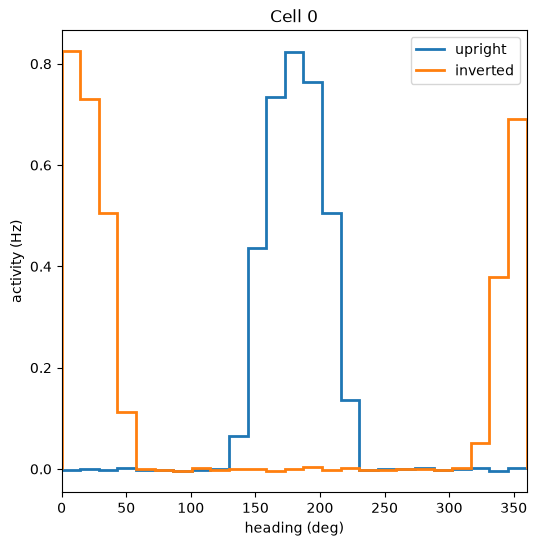

In [5]:
cell_index = 0
fig,ax = plt.subplots(1,1,figsize=(6,6))
upright_map,upright_counts,upright_edges = activity_map(sphere_heading[:upright_index,0],recording["yaw_cells"][:upright_index,cell_index])
inverted_map,inverted_counts, inverted_edges = activity_map(sphere_heading[inverted_index:,0],recording["yaw_cells"][inverted_index:,cell_index])
ax.stairs(upright_map, upright_edges[0], label="upright",color="C0",lw=2)
ax.stairs(inverted_map, inverted_edges[0], label="inverted",color="C1",lw=2)
ax.set_xlabel("heading (deg)")
ax.set_ylabel("activity (Hz)")
ax.set_xlim(inverted_edges[0][[0,-1]])
ax.set_title(f"Cell {cell_index}")
ax.legend()
fig.savefig(os.path.join(PLOTS_DIR, f"cell_{cell_index}_activity_map.svg"))

In [38]:
v_yaw_full_turn = 0
v_pitch_full_turn = 1

duration = 2 * np.pi / v_pitch_upright

t_session = np.arange(0,duration,step=dt)


angular_velocity_full_turn =  np.stack([v_yaw_full_turn * np.ones_like(t_session),v_pitch_full_turn * np.ones_like(t_session)],axis=-1)
toroid_heading_full_turn = np.stack([v_yaw_full_turn * t_session,(v_pitch_full_turn * t_session+np.pi - np.pi / 2) % (2 * np.pi)-np.pi],axis=-1)
sphere_heading_full_turn = sphere_from_toroid(toroid_heading_full_turn)

toroid_heading_full_turn = np.rad2deg(toroid_heading_full_turn)
sphere_heading_full_turn = np.rad2deg(sphere_heading_full_turn + np.array([0,0]))
inversion_full_turn = np.abs(toroid_heading_full_turn[...,1]) > 90


In [42]:
recording_full_turn = net_anchor.run_simulation(
    angular_velocity_full_turn,
    inverted = inversion_full_turn
)

Running Simulation Steps: 100%|██████████| 12567/12567 [00:02<00:00, 4660.46it/s]


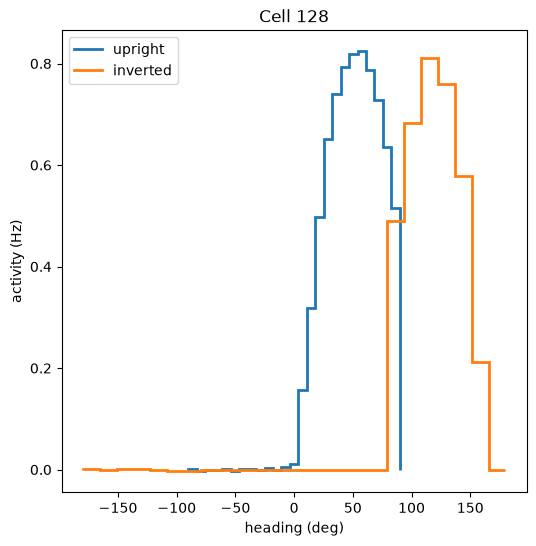

In [46]:
cell_index = n//2
fig,ax = plt.subplots(1,1,figsize=(6,6))
upright_map,upright_counts,upright_edges = activity_map(toroid_heading_full_turn[~inversion_full_turn,1],recording_full_turn["pitch_cells"][~inversion_full_turn,cell_index])
inverted_map,inverted_counts, inverted_edges = activity_map(toroid_heading_full_turn[inversion_full_turn,1],recording_full_turn["pitch_cells"][inversion_full_turn,cell_index])
ax.stairs(upright_map, upright_edges[0], label="upright",color="C0",lw=2)
ax.stairs(inverted_map, inverted_edges[0], label="inverted",color="C1",lw=2)
ax.set_xlabel("heading (deg)")
ax.set_ylabel("activity (Hz)")
ax.set_title(f"Cell {cell_index}")
ax.legend()
fig.savefig(os.path.join(PLOTS_DIR, f"cell_{cell_index}_activity_map.svg"))